# Bayesian linear mixture model

In [1]:
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
import os 
import arviz as az
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = gpd.read_file('updated_data.geojson')

# selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman"]
# X=df[selected_covariates].to_numpy()

# new_selected_covariates = ["coverage", "public_coverage","per_capita_public_expenditure","other_percapita_public_expenditure","other_percapita_user_contrib","ecec_diffusion","fertility_rate","GDP","young_neet", "internet_coverage_rate", "fem_house_rate"]
new_selected_covariates = ["coverage", "public_coverage","per_capita_public_expenditure","other_percapita_public_expenditure","other_percapita_user_contrib","ecec_diffusion","GDP","young_neet", "internet_coverage_rate"]
X=df[new_selected_covariates].to_numpy()

# print(len(selected_covariates))



y=df["fem_empl_rate"].to_numpy()


Normalization and logit

In [3]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y = y/100
y_scaled = np.log(y/(1-y)) 



## Computation of the proximity matrix W

In [4]:
n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1



Stan Model

In [5]:
str_model="""


functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of V
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}


data {
    // Data
    int N;
    int P;

    int K; //nb of clusters

    matrix[N, P] X;
    array[N] real y;

    //proximity matrix
    matrix[N, N] W;

    
    // Prior parameters
    array[4] real p0_params;
    real ai_dir; //in our model alpha=1 for dirichlet prior

    real tau20;
    real tau21;
}

transformed data {
    real a0 = p0_params[1];
    real b0 = p0_params[2];
    real sigma0 = p0_params[3];
    real sigma1 = p0_params[4];

        //Vectors needed for Car Prior
    vector[N] D;            // diagonal entries of D
    vector[N] lambda;       // eigenvalues of D-W
    for (i in 1:N)
        D[i] = sum(W[i]);     //sum of the colomns of W for one row i.
    lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
    array[K] real alpha;
    matrix[K,P] beta; 

    array[K] real<lower=0.00001> sigma;

    simplex[K] weights;

    vector[N] phi;
    real<lower=0> tau2;
    real<lower=0 , upper=1> rho;
}

transformed parameters {
    matrix[N,K] mu;
    for(i in 1:N) {
        for(k in 1:K) {

            mu[i,k] = dot_product(row(X, i), beta[k]) + alpha[k];
        }
        
    }
}


model {

    vector[K] contributions;
    for (i in 1:N) {
        for(k in 1:K) {
            contributions[k] = log(weights[k]) + normal_lpdf(y[i] | mu[i,k] + phi[i], sigma[k]);
            // y[i] ~ normal(mu[i], sigma);  

            }
            target += log_sum_exp(contributions);
        }

        
    
    weights ~ dirichlet(rep_vector(ai_dir, K));

    for(k in 1:K) {
        alpha[k] ~ normal(0, a0);

        for (j in 1:P) {
            beta[k,j] ~ normal(0, b0);
        }
        
        sigma[k] ~ inv_gamma(sigma0, sigma1);
        //sigma[k] ~ normal(0, 1);
        //sigma[k] ~ cauchy(0, 1);

        
    }

    phi ~ car_leroux(tau2, rho, W, D, lambda, N);
    tau2 ~ inv_gamma(tau20, tau21);
    rho ~ beta(2,2);
}

generated quantities {
    array[N] int cluster_allocs;
    for(i in 1:N){
        vector[K] log_probs = log(weights);
        for(k in 1:K) {
            log_probs[k] += normal_lpdf(y[i] | mu[i,k], sigma[k]);
        }
        cluster_allocs[i] = categorical_rng(softmax(log_probs))-1;
    }
}

"""


if not os.path.exists("./stan"):
    os.mkdir("./stan")
stan_file = "./stan/linear_model.stan"
with open(stan_file, "w") as f:
    print(str_model, file=f)

# Compile stan model
linear_model = CmdStanModel(stan_file=stan_file)

21:35:49 - cmdstanpy - INFO - compiling stan file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model.stan to exe file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model
21:36:20 - cmdstanpy - INFO - compiled model executable: /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model


In [127]:
K=5
N=len(y_scaled)
P=X.shape[1]
gmm_data = {
    "N": N,
    "P":P,
    "K":K,

    "X":X_scaled,
    "y": y_scaled,
    
    "W":W,

    "p0_params": np.array([1, 1, 2, 1]),
    "ai_dir":10,
    "tau20":3,
    "tau21":2
}

# Algorithm parameters
algo_params = {
    "n_chains": 5,
    "n_burnin": 1000,
    "n_iter": 1000,
    "max_treedepth":12
}

# Sample
model = linear_model.sample(data=gmm_data, chains=algo_params["n_chains"], parallel_chains=algo_params["n_chains"],
                                  iter_warmup=algo_params["n_burnin"], iter_sampling=algo_params["n_iter"],max_treedepth=algo_params["max_treedepth"])

# control={"max_treedepth": algo_params["max_treedepth"]}
# Convert to arviz data type
chains = az.from_cmdstanpy(model)

22:40:38 - cmdstanpy - INFO - CmdStan start processing




















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































22:41:08 - cmdstanpy - INFO - CmdStan done processing.


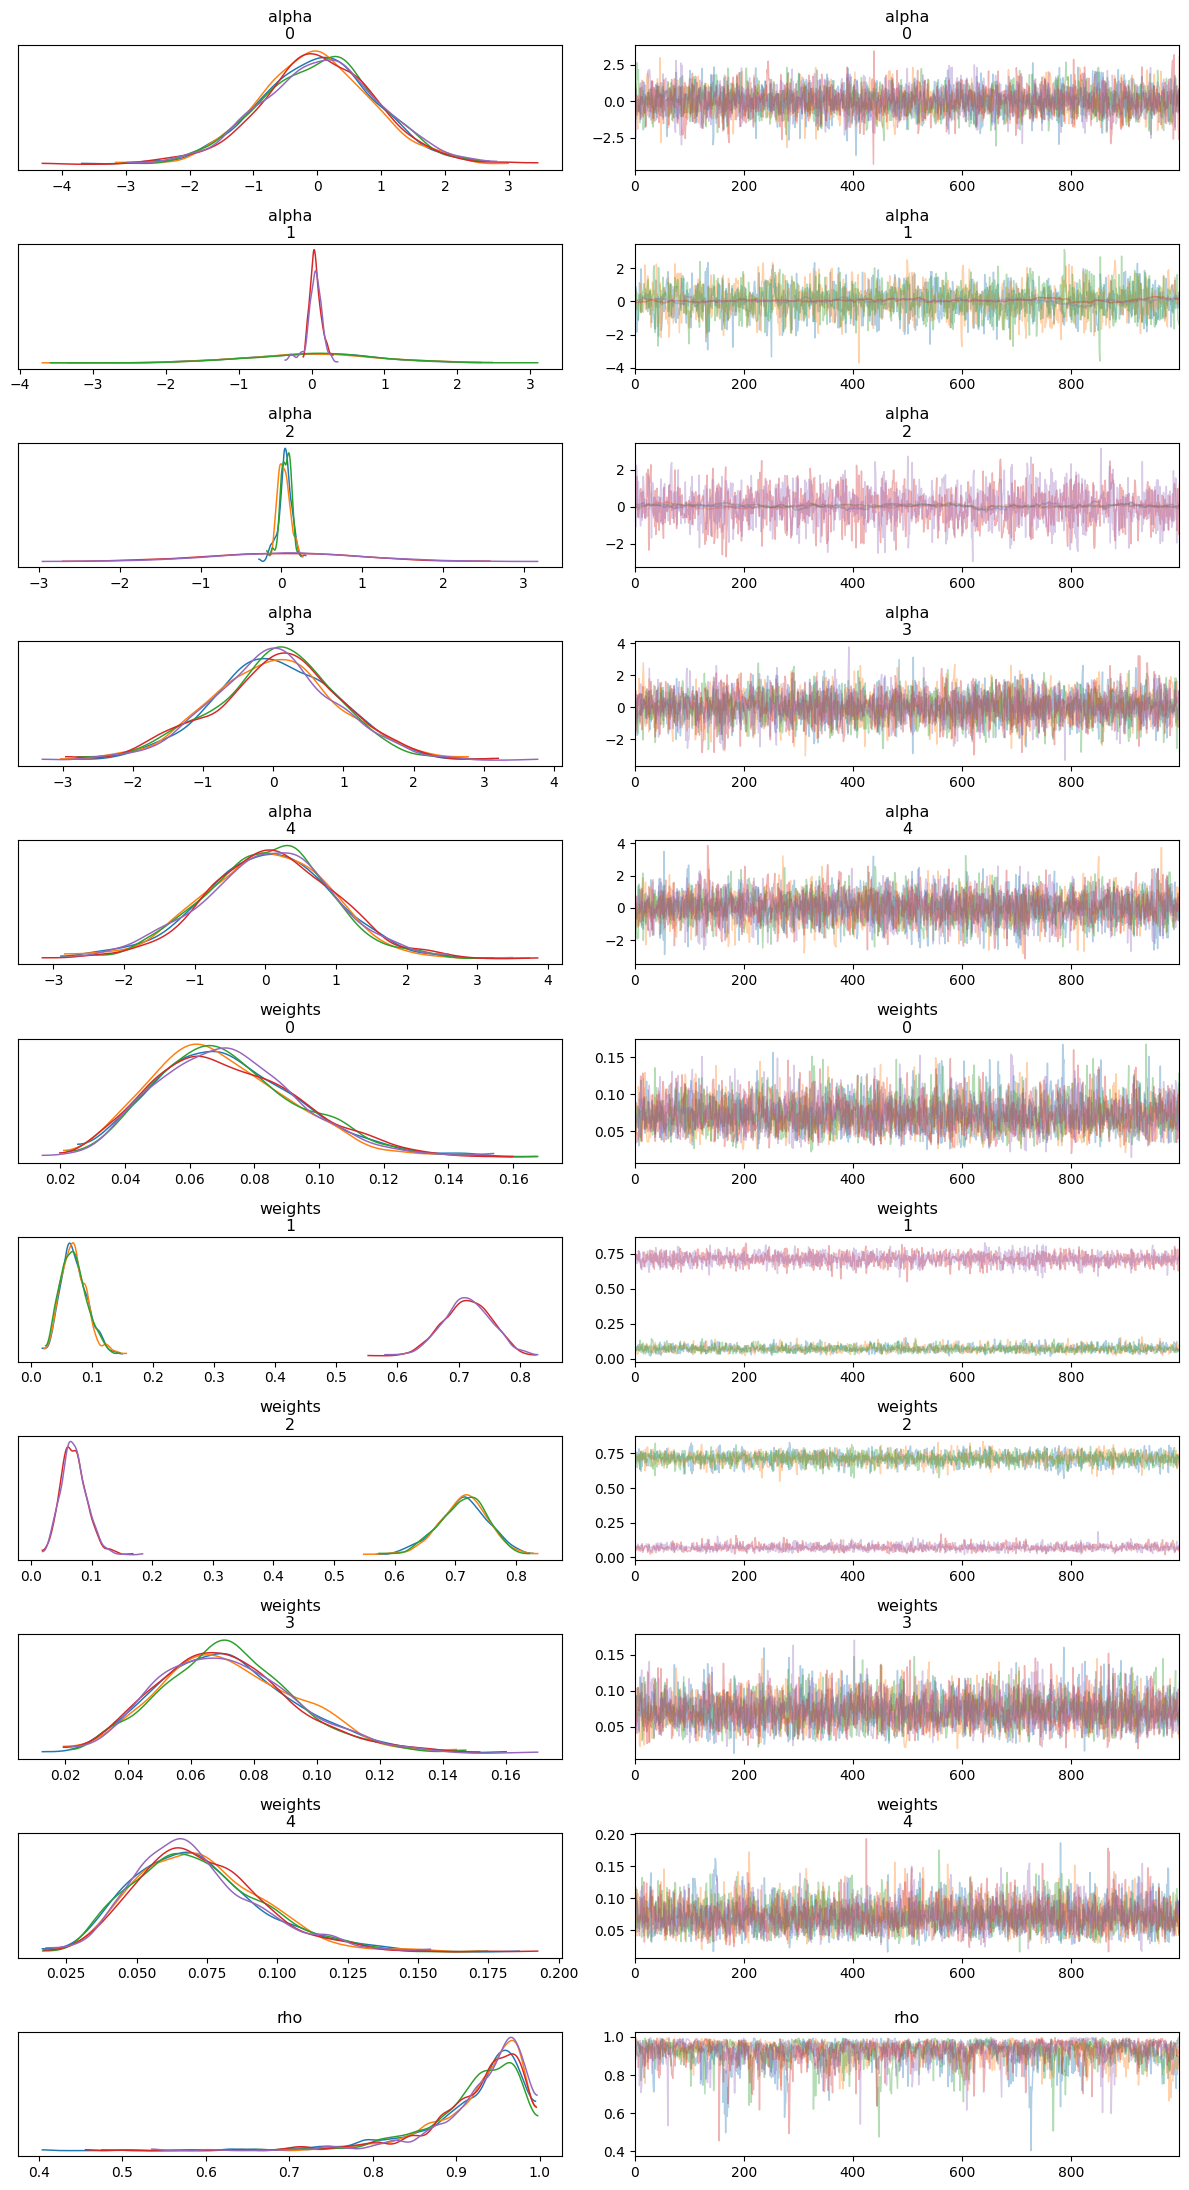

In [128]:
az.plot_trace(chains, var_names=["alpha","weights","rho"], compact=False)
plt.tight_layout()
plt.show()

## In this part, we want to assign y_i to a cluster (0,1,2)

In [129]:
# Function that computes the posterior similarity matrix
def get_psm(clus_alloc_chain):
    c_chain = np.vstack(clus_alloc_chain)
    out = np.zeros((c_chain.shape[1], c_chain.shape[1]))
    for i in range(c_chain.shape[1]):
        for j in range(i):
            out[i, j] = np.mean(c_chain[:, i] == c_chain[:, j])
    return out + out.T + np.eye(out.shape[0])



In [130]:
# Function that computes the cluster estimate that minimizes the binder loss function
def minbinder_sample(clus_alloc_chain, psm):
    losses = np.zeros(len(clus_alloc_chain))
    c_chain = np.vstack(clus_alloc_chain)
    for i in range(c_chain.shape[1]):
        for j in range(i):
            losses += (np.mean(c_chain[:, i] == c_chain[:, j]) - psm[i, j]) ** 2
    best_iter = np.argmin(losses)
    return clus_alloc_chain[best_iter]

In [131]:
print(chains.posterior.cluster_allocs.shape)

(5, 1000, 107)


In [132]:
# Retrieve cluster allocation variables
clust_allocs_chain = np.vstack(chains.posterior.cluster_allocs)

In [133]:
# Compute posterior similarity matrix
psm = get_psm(clust_allocs_chain)

In [134]:
# Compute point estimate of the cluster
best_clus = minbinder_sample(clust_allocs_chain, psm)

## Visualization of the results

[2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 2. 3. 2. 2. 2. 2. 1.
 2. 2. 2. 2. 2. 2. 3. 2. 0. 3. 2. 2. 2. 2. 2. 2. 3. 2. 2. 2. 0. 2. 2. 4.
 2. 2. 2. 1. 0. 2. 2. 2. 2. 2. 2. 2. 2. 3. 4. 2. 2. 2. 2. 2. 3. 1. 3. 2.
 2. 2. 1. 3. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 4. 2. 2. 3. 4. 3. 2. 3. 2. 2.]


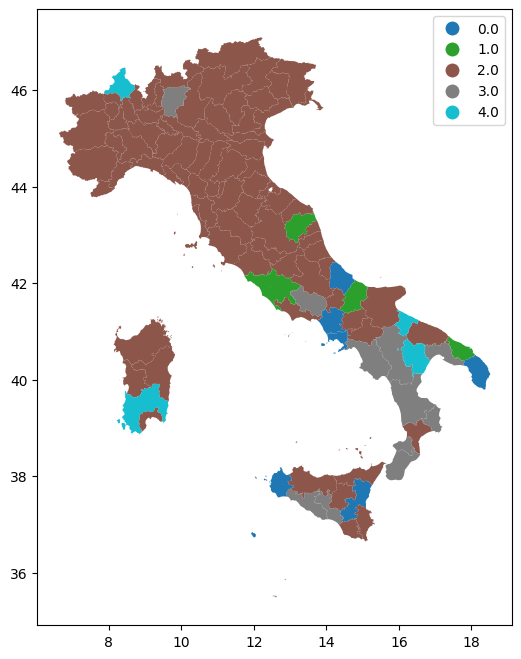

In [135]:
from matplotlib.colors import ListedColormap

# Plot the point cluster estimate on the empirical density histogram
# plt.hist(data, density=True, alpha=0.3)


color_map = {
    0: "red",      # couleur1
    1: "blue",     # couleur2
    2: "green"     # etc.
}

print(best_clus)

df["cluster_bayes"] = best_clus


# df.plot(column="cluster_bayes", categorical=True, legend=True)
# cmap = ListedColormap(["blue", "red","green"])
# cmap = ListedColormap(["green", "red","blue"])
# cmap = ListedColormap(["green", "red", "blue", "orange", "purple"])
cmap = ListedColormap(["purple", "green", "blue", "orange", "red"])



ax = df.plot(
    column="cluster_bayes",
    categorical=True,
    # cmap=cmap,
    legend=True,
    figsize=(8, 8)
)

plt.show()



In [136]:
print("model.summary",model.summary()[:20])


model.summary                 Mean      MCSE     StdDev        MAD        5%        50%  \
lp__       87.819500  0.509501  14.540000  14.318000  63.07750  88.090800   
alpha[1]    0.016748  0.014034   0.909310   0.878553  -1.45949   0.022410   
alpha[2]    0.024421  0.011968   0.686963   0.313657  -1.22842   0.045123   
alpha[3]    0.037713  0.009038   0.584671   0.139744  -1.03225   0.045577   
alpha[4]    0.026188  0.013423   0.899444   0.862933  -1.49256   0.041792   
alpha[5]    0.029859  0.014369   0.907727   0.890489  -1.48140   0.044491   
beta[1,1]   0.000452  0.014672   0.929990   0.915254  -1.55496   0.011366   
beta[1,2]   0.016445  0.014679   0.933452   0.923792  -1.53060   0.014620   
beta[1,3]  -0.019643  0.015146   0.953719   0.949474  -1.62729  -0.002897   
beta[1,4]   0.007281  0.014172   0.936596   0.937427  -1.50813   0.006125   
beta[1,5]  -0.002333  0.015934   0.982269   0.950745  -1.61206  -0.001827   
beta[1,6]  -0.009852  0.014767   0.927658   0.894204  -1.53922